In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/donnees_salaires_developpeurs.csv")

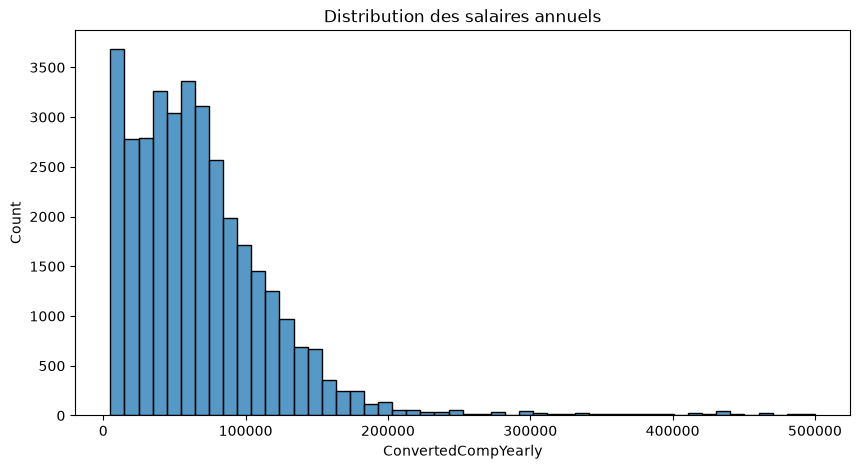

In [2]:
plt.figure(figsize=(10,5))
sns.histplot(df["ConvertedCompYearly"], bins=50)
plt.title("Distribution des salaires annuels")
plt.savefig("../outputs/figures/distribution_salaires.png")
plt.show()

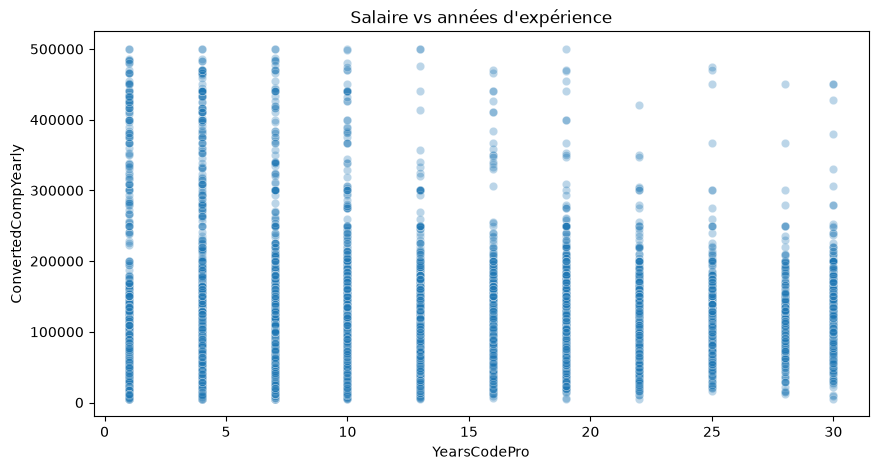

In [3]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="YearsCodePro", y="ConvertedCompYearly", alpha=0.3)
plt.title("Salaire vs années d'expérience")
plt.savefig("../outputs/figures/salaire_vs_experience.png")
plt.show()

In [4]:
top_pays = df.groupby("Country")["ConvertedCompYearly"].agg(["median","count"])
top_pays = top_pays[top_pays["count"] >= 50].sort_values("median", ascending=False).head(10)
top_pays

,median,count
Country,,
United States,100000.0,10790
Switzerland,96971.0,366
Israel,93672.0,360
Denmark,82838.0,264
Norway,80595.0,270
Australia,79973.0,894
Ireland,72209.0,215
New Zealand,65776.0,222
Canada,64417.0,1520


In [5]:
df_langages = df.copy()
df_langages["LanguageHaveWorkedWith"] = df_langages["LanguageHaveWorkedWith"].str.split(";")
df_langages = df_langages.explode("LanguageHaveWorkedWith")

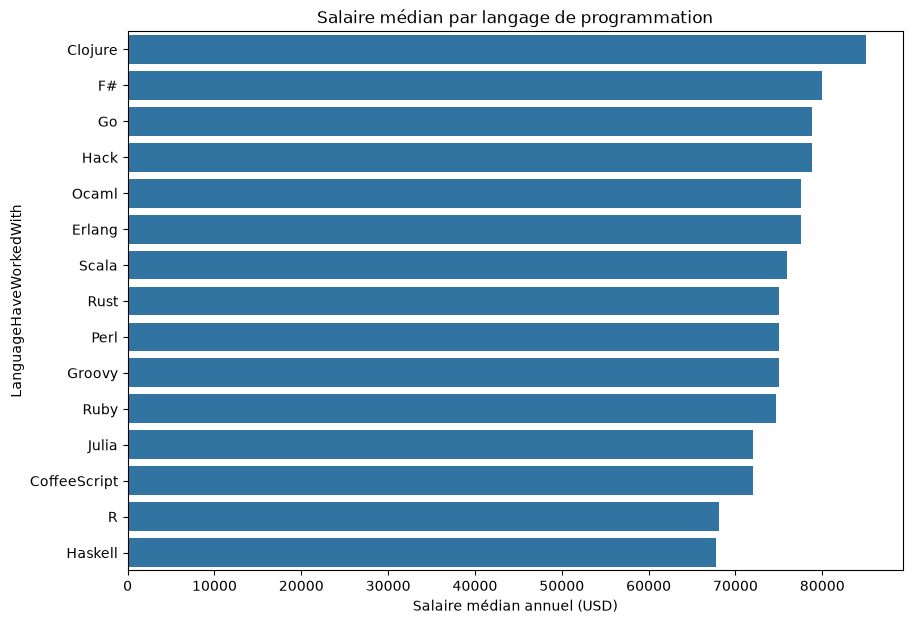

In [6]:
top_langages = df_langages.groupby("LanguageHaveWorkedWith")["ConvertedCompYearly"].agg(["median","count"])
top_langages = top_langages[top_langages["count"] >= 50].sort_values("median", ascending=False).head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_langages["median"], y=top_langages.index)
plt.title("Salaire médian par langage de programmation")
plt.xlabel("Salaire médian annuel (USD)")
plt.savefig("../outputs/figures/salaire_par_langage.png")
plt.show()

In [7]:
edlevel_salaire = df.groupby("EdLevel")["ConvertedCompYearly"].median().sort_values(ascending=False)
edlevel_salaire

EdLevel
Other doctoral degree (Ph.D, Ed.D., etc.)                                             78427.5
Bachelor’s degree (BA, BS, B.Eng., etc.)                                              62507.0
Master’s degree (MA, MS, M.Eng., MBA, etc.)                                           60000.0
Associate degree                                                                      58746.0
I never completed any formal education                                                58014.0
Some college/university study without earning a degree                                55562.0
Primary/elementary school                                                             49423.0
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    44916.0
Professional degree (JD, MD, etc.)                                                    32268.0
Name: ConvertedCompYearly, dtype: float64

## Interprétation des résultats

Dans cet échantillon de répondants à l’enquête Stack Overflow 2018, les salaires médians varient selon les langages déclarés. Certains langages spécialisés peuvent présenter des médianes plus élevées, mais cet écart descriptif ne démontre pas qu’un langage cause une rémunération supérieure : l’expérience, le pays et le type d’emploi peuvent aussi l’expliquer.

Le nuage de points permet d’observer la relation entre expérience professionnelle et salaire ; elle semble globalement croissante, avec une forte dispersion. Le niveau d’études doit être interprété avec la même prudence. Ces tendances seront à confronter à l’importance des variables du modèle dans le Notebook 04 et ne constituent pas, à elles seules, une conclusion causale.